# Retail Sales & Customer Insights Analysis

**Goal:** clean a messy retail sales export and turn it into a set of
business-ready insights on revenue, profit, and customer behaviour.

**Dataset:** a synthetic e-commerce order log (3,200+ rows) covering two
years of orders across four Indian regions and five product categories.
It was generated for this project and intentionally includes the kind of
mess a real export usually has — inconsistent text casing, missing values,
and duplicate rows — so the cleaning step below is doing real work, not
just a formality.

**Tools:** NumPy, pandas, Matplotlib, Seaborn.

**Sections**
1. Load and inspect the raw data
2. Data cleaning
3. Feature engineering
4. Exploratory analysis & visualizations
5. Business insights summary


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#12523A", "#1E6E4E", "#C77D2E", "#545C55", "#9C5D1C"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)


## 1. Load and inspect the raw data

First look at the file the way it actually arrives — before assuming
anything about its quality.

In [2]:
raw = pd.read_csv("data/raw_sales_data.csv", parse_dates=["OrderDate"])
print(raw.shape)
raw.head()


(3225, 12)


,OrderID,OrderDate,CustomerID,CustomerSegment,Region,State,Category,Product,Quantity,UnitPrice,DiscountPercent,PaymentMethod
0,ORD10377,2025-03-26,CUST1393,Corporate,north,Delhi,Home & Kitchen,Storage Box,1.0,721.36,5.0,Debit Card
1,ORD11949,2024-04-04,CUST1090,Consumer,East,Jharkhand,Electronics,Smartwatch,1.0,2695.48,0.0,UPI
2,ORD12440,2024-11-29,CUST1466,Consumer,South,Karnataka,Electronics,Power Bank,1.0,2934.36,0.0,Cash on Delivery
3,ORD10180,2025-07-02,CUST1372,Consumer,West,Maharashtra,Grocery,Green Tea,3.0,484.42,NaN,UPI
4,ORD11078,2025-07-14,CUST1430,Corporate,North,Haryana,Beauty,Hair Serum,1.0,688.55,0.0,UPI


In [3]:
raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 3225 entries, 0 to 3224
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          3225 non-null   str           
 1   OrderDate        3225 non-null   datetime64[us]
 2   CustomerID       3198 non-null   str           
 3   CustomerSegment  3225 non-null   str           
 4   Region           3225 non-null   str           
 5   State            3225 non-null   str           
 6   Category         3225 non-null   str           
 7   Product          3225 non-null   str           
 8   Quantity         3174 non-null   float64       
 9   UnitPrice        3170 non-null   float64       
 10  DiscountPercent  3161 non-null   float64       
 11  PaymentMethod    3225 non-null   str           
dtypes: datetime64[us](1), float64(3), str(8)
memory usage: 302.5 KB


In [4]:
# Quick data-quality check
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])

print("\nDuplicate rows:", raw.duplicated().sum())

print("\nDistinct 'Category' spellings before cleaning:")
print(sorted(raw["Category"].unique()))

print("\nDistinct 'Region' spellings before cleaning:")
print(sorted(raw["Region"].unique()))


Missing values per column:
CustomerID         27
Quantity           51
UnitPrice          55
DiscountPercent    64
dtype: int64

Duplicate rows: 25

Distinct 'Category' spellings before cleaning:
[' APPAREL ', ' Apparel ', ' Beauty ', ' Electronics ', ' GROCERY ', ' Grocery ', ' Home & Kitchen ', ' apparel ', ' beauty ', ' electronics ', ' home & kitchen ', 'APPAREL', 'Apparel', 'BEAUTY', 'Beauty', 'ELECTRONICS', 'Electronics', 'GROCERY', 'Grocery', 'HOME & KITCHEN', 'Home & Kitchen', 'apparel', 'beauty', 'electronics', 'grocery', 'home & kitchen']

Distinct 'Region' spellings before cleaning:
['East', 'North', 'South', 'West', 'east', 'north', 'south', 'west']


**Issues found:**
- `Category` and `Region` have inconsistent casing and stray whitespace
  (`" Electronics "`, `"electronics"`, `"ELECTRONICS"` are all the same
  category).
- `Quantity`, `UnitPrice`, and `DiscountPercent` have missing values.
- `CustomerID` is missing for a small number of rows.
- There are exact duplicate rows, likely from a repeated export or
  double-submitted orders.

Each of these gets fixed explicitly below rather than dropped silently,
so the cleaning is auditable.

## 2. Data cleaning

In [5]:
df = raw.copy()

# --- standardise text categories: strip whitespace, fix casing ---
df["Category"] = df["Category"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()

print("Categories after cleaning:", sorted(df["Category"].unique()))
print("Regions after cleaning:", sorted(df["Region"].unique()))


Categories after cleaning: ['Apparel', 'Beauty', 'Electronics', 'Grocery', 'Home & Kitchen']
Regions after cleaning: ['East', 'North', 'South', 'West']


In [6]:
# --- remove exact duplicate rows ---
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")


Dropped 25 duplicate rows


In [7]:
# --- handle missing values ---
# Quantity: missing almost always means a single unit was ordered
df["Quantity"] = df["Quantity"].fillna(1)

# UnitPrice: impute using the median price for that specific product,
# not a single global median, since prices vary a lot across categories
df["UnitPrice"] = df.groupby("Product")["UnitPrice"].transform(
    lambda s: s.fillna(s.median())
)

# DiscountPercent: no discount recorded is treated as no discount applied
df["DiscountPercent"] = df["DiscountPercent"].fillna(0)

# CustomerID: a handful of rows have no ID captured at checkout;
# keep the rows (the sale still happened) but flag them clearly
df["CustomerID"] = df["CustomerID"].fillna("UNKNOWN")

print(df.isna().sum().sum(), "missing values remaining")


0 missing values remaining


In [8]:
# --- sanity-check numeric ranges (catch impossible values) ---
print(df[["Quantity", "UnitPrice", "DiscountPercent"]].describe())
assert df["DiscountPercent"].between(0, 100).all()
assert (df["Quantity"] > 0).all()


          Quantity    UnitPrice  DiscountPercent
count  3200.000000  3200.000000      3200.000000
mean      1.426562  1259.810239         7.498437
std       0.775674   863.170132         8.004180
min       1.000000    89.460000         0.000000
25%       1.000000   557.075000         0.000000
50%       1.000000   946.560000         5.000000
75%       2.000000  1940.635000        10.000000
max       4.000000  3496.350000        30.000000


## 3. Feature engineering

Turn the raw order-level fields into the metrics the business actually
cares about: revenue, profit, and margin, plus time features for
trend analysis.

In [9]:
# category-level cost ratio, used to model a realistic profit margin
COST_RATIO = {
    "Electronics": 0.72,
    "Apparel": 0.55,
    "Home & Kitchen": 0.60,
    "Beauty": 0.45,
    "Grocery": 0.78,
}

df["Sales"] = (df["UnitPrice"] * df["Quantity"] * (1 - df["DiscountPercent"] / 100)).round(2)
df["UnitCost"] = df["Category"].map(COST_RATIO) * df["UnitPrice"]
df["Profit"] = (df["Sales"] - df["UnitCost"] * df["Quantity"]).round(2)
df["ProfitMargin"] = (df["Profit"] / df["Sales"]).round(3)

df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderYear"] = df["OrderDate"].dt.year
df["Weekday"] = df["OrderDate"].dt.day_name()

df[["OrderID", "Category", "Quantity", "UnitPrice", "DiscountPercent", "Sales", "Profit", "ProfitMargin"]].head()


,OrderID,Category,Quantity,UnitPrice,DiscountPercent,Sales,Profit,ProfitMargin
0,ORD10377,Home & Kitchen,1.0,721.36,5.0,685.29,252.47,0.368
1,ORD11949,Electronics,1.0,2695.48,0.0,2695.48,754.73,0.280
2,ORD12440,Electronics,1.0,2934.36,0.0,2934.36,821.62,0.280
3,ORD10180,Grocery,3.0,484.42,0.0,1453.26,319.72,0.220
4,ORD11078,Beauty,1.0,688.55,0.0,688.55,378.70,0.550


In [10]:
df.to_csv("data/cleaned_sales_data.csv", index=False)
print("Saved cleaned dataset:", df.shape)


Saved cleaned dataset: (3200, 19)


## 4. Exploratory analysis & visualizations

### Monthly revenue trend

Is revenue growing, flat, or seasonal over the two years of data?

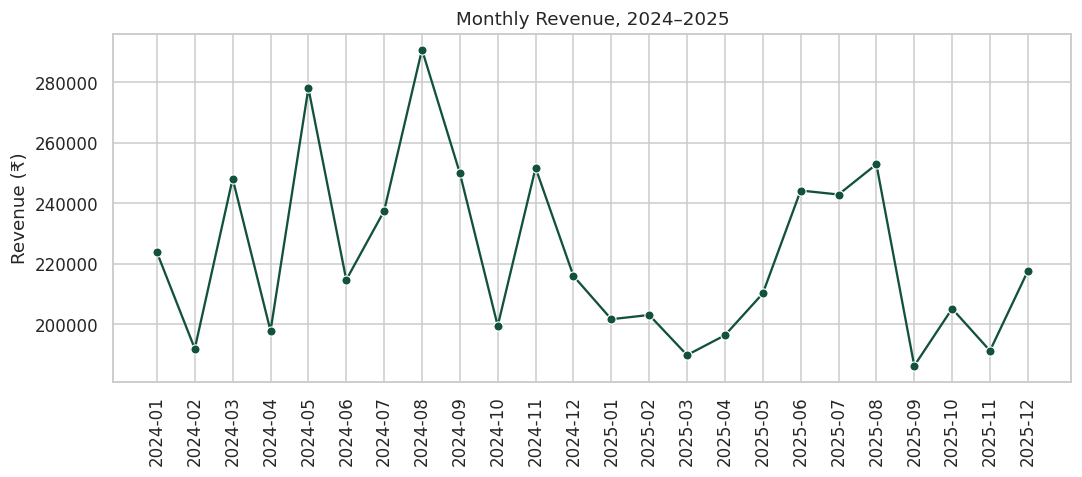

In [11]:
monthly = df.groupby("OrderMonth")["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=monthly, x="OrderMonth", y="Sales", marker="o", color="#12523A", ax=ax)
ax.set_title("Monthly Revenue, 2024–2025")
ax.set_xlabel("")
ax.set_ylabel("Revenue (₹)")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
fig.savefig("charts/01_monthly_revenue_trend.png")
plt.show()


### Revenue and profit by region

Which regions drive the most revenue, and does that translate into profit?

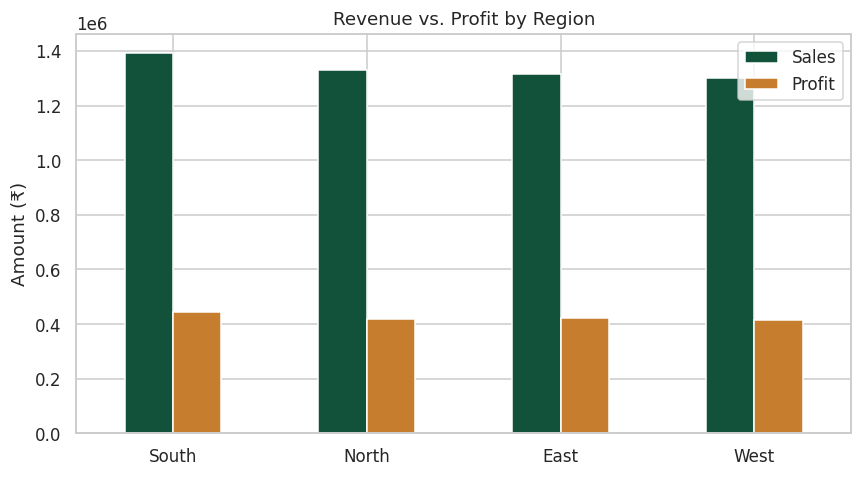

,Sales,Profit
Region,,
South,1392824.15,445979.88
North,1331426.98,420158.86
East,1317026.42,420875.72
West,1301097.37,416476.98


In [12]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
region_summary.plot(kind="bar", ax=ax, color=["#12523A", "#C77D2E"])
ax.set_title("Revenue vs. Profit by Region")
ax.set_ylabel("Amount (₹)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig("charts/02_region_revenue_profit.png")
plt.show()

region_summary


### Profit margin by category

Revenue share doesn't tell the whole story — margin does.

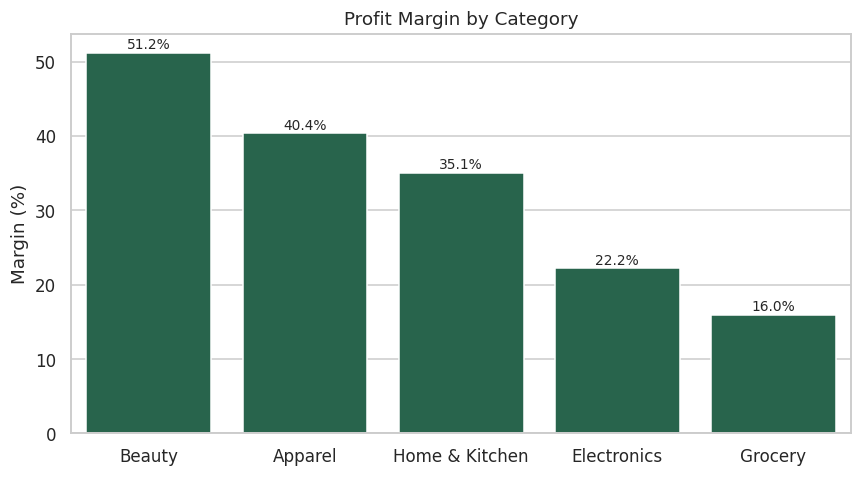

In [13]:
category_margin = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
).reset_index()
category_margin["MarginPct"] = (category_margin["Profit"] / category_margin["Sales"] * 100).round(1)
category_margin = category_margin.sort_values("MarginPct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=category_margin, x="Category", y="MarginPct", color="#1E6E4E", ax=ax)
ax.set_title("Profit Margin by Category")
ax.set_ylabel("Margin (%)")
ax.set_xlabel("")
for i, v in enumerate(category_margin["MarginPct"]):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig("charts/03_category_margin.png")
plt.show()


### Discount vs. profit margin

Do heavier discounts actually hurt margin as much as expected?

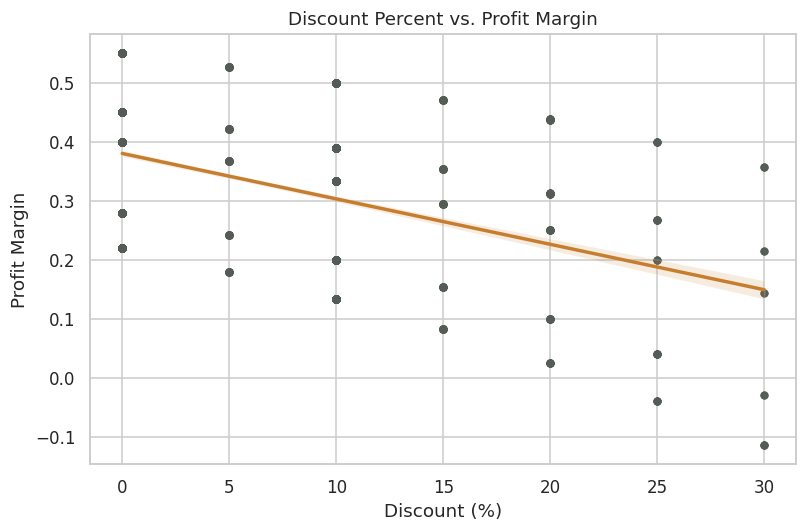

Correlation (discount, margin): -0.432


In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.regplot(
    data=df, x="DiscountPercent", y="ProfitMargin",
    scatter_kws={"alpha": 0.25, "s": 18, "color": "#545C55"},
    line_kws={"color": "#C77D2E"},
    ax=ax,
)
ax.set_title("Discount Percent vs. Profit Margin")
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit Margin")
fig.tight_layout()
fig.savefig("charts/04_discount_vs_margin.png")
plt.show()

print("Correlation (discount, margin):", round(df["DiscountPercent"].corr(df["ProfitMargin"]), 3))


### Top-selling products

Which individual products should stay well stocked?

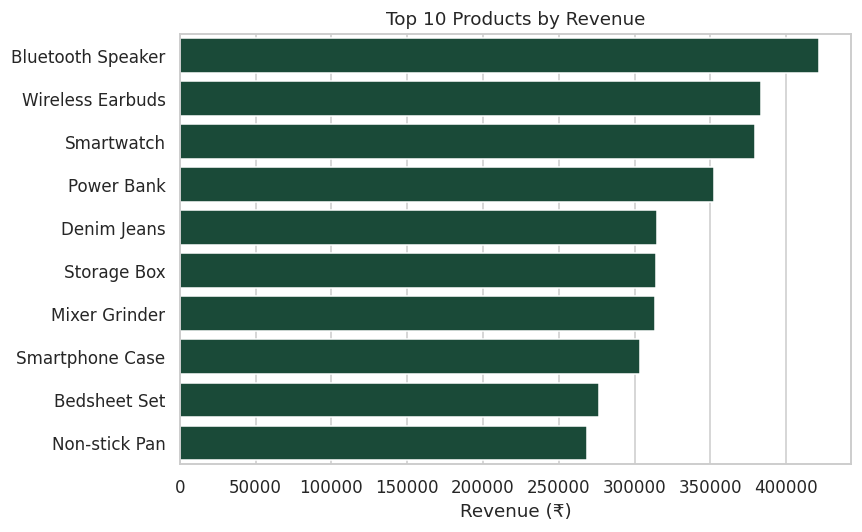

In [15]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_products.values, y=top_products.index, color="#12523A", ax=ax)
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("charts/05_top_products.png")
plt.show()


### Sales distribution by category (spotting outliers)

A boxplot shows the spread of individual order values, not just the
category total — useful for spotting unusually large or small orders.

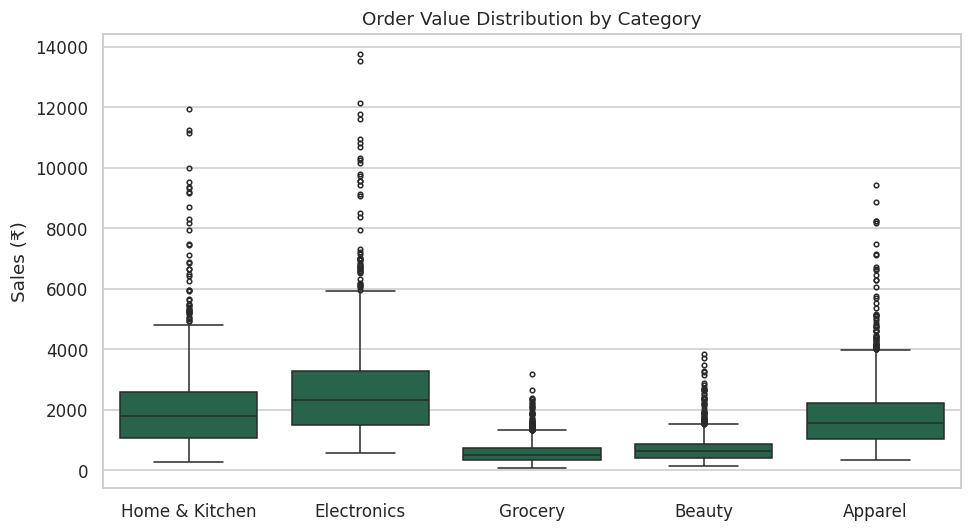

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Category", y="Sales", color="#1E6E4E", ax=ax, fliersize=3)
ax.set_title("Order Value Distribution by Category")
ax.set_xlabel("")
ax.set_ylabel("Sales (₹)")
fig.tight_layout()
fig.savefig("charts/06_sales_distribution_boxplot.png")
plt.show()


### Customer segment mix

How is revenue split across consumer, corporate, and home-office buyers?

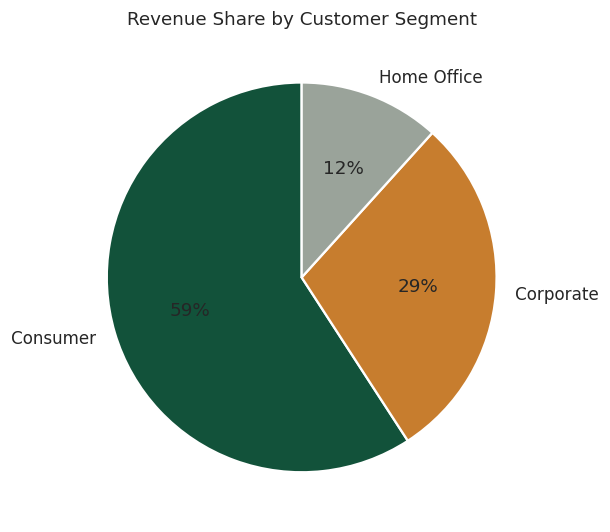

In [17]:
segment_sales = df.groupby("CustomerSegment")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#12523A", "#C77D2E", "#9AA39A"]
ax.pie(
    segment_sales.values, labels=segment_sales.index, autopct="%1.0f%%",
    colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Revenue Share by Customer Segment")
fig.tight_layout()
fig.savefig("charts/07_customer_segment_mix.png")
plt.show()


### Correlation heatmap

A single view of how the numeric fields relate to each other.

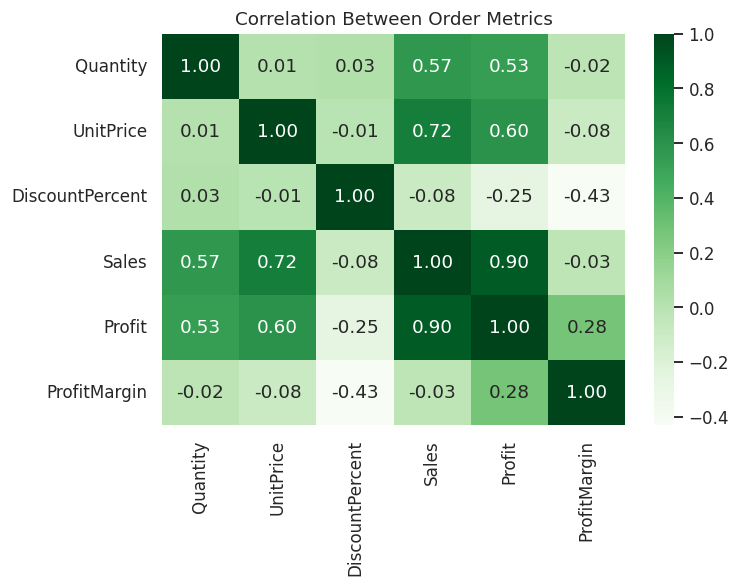

In [18]:
numeric_cols = ["Quantity", "UnitPrice", "DiscountPercent", "Sales", "Profit", "ProfitMargin"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", cbar=True, ax=ax)
ax.set_title("Correlation Between Order Metrics")
fig.tight_layout()
fig.savefig("charts/08_correlation_heatmap.png")
plt.show()


## 5. Business insights summary

- **Electronics brings in the most revenue but not the best margin.**
  It has the highest cost ratio of any category, so pushing volume there
  grows revenue faster than it grows profit — worth watching if discounting
  increases.
- **Discounting has a clear negative relationship with margin** (see the
  correlation above), which is expected — but the scatter shows a wide
  spread at every discount level, meaning margin is not determined by
  discount alone; product mix matters too.
- **Beauty carries the strongest margin, Grocery the thinnest.** Beauty
  runs at roughly 51% margin against Grocery's 16%, even though Grocery
  isn't the lowest revenue category — a signal to price or bundle Grocery
  items more carefully rather than compete on volume alone.
- **Consumer segment dominates revenue share**, so most of the business's
  exposure sits with individual buyers rather than corporate accounts —
  relevant for planning promotions or loyalty programs.
- **Revenue by region is uneven**, which is worth pairing with marketing
  spend by region to see whether the gap reflects market size or
  under-investment.

### How this maps to an internship
This mirrors the actual sequence of a real reporting task: audit a messy
export, document and fix its specific problems, engineer the metrics the
business asks about, then visualize and summarize findings in plain
language rather than raw numbers.
